In [1]:
import numpy as np
import pandas as pd
%matplotlib widget
import matplotlib.pyplot as plt
import os
import sys
import h5py
from biosppy.signals import ecg
sys.path.append('/home/wolfgang/repos/sleep_research_io')
from sleep_research_functions import load_sleep_data, write_to_hdf5_file, get_metadata
import pickle

In [2]:
import scipy
scipy.__version__

'1.2.0'

In [3]:
# Function to remove artifacts from RR peaks
def adarri_artifact_removal(
    rpeaks: np.ndarray, ecg_lead: np.ndarray
) -> np.ndarray:
    adarri = np.log1p(np.abs(np.diff(np.diff(rpeaks))))
    artifact_pos = np.where(adarri >= 5)[0] + 2
    rpeak_q10, rpeak_q90 = np.percentile(ecg_lead[rpeaks], (10, 90))
    artifact_pos = (
        artifact_pos.tolist()
        + np.where(
            (ecg_lead[rpeaks] < rpeak_q10 - 300)
            | (ecg_lead[rpeaks] > rpeak_q90 + 300)
        )[0].tolist()
    )
    artifact_pos = np.sort(np.unique(artifact_pos))
    rpeaks_noart = rpeaks
    if len(artifact_pos) != 0:
        rpeaks_noart = np.delete(rpeaks, artifact_pos)

    return rpeaks_noart

In [4]:
ecg_dir = '/media/mad3/Projects/ICU_SLEEP_STUDY/data/data_analysis/BMR_resampled_ECG'
vitals_dir = '/media/mad3/Projects/ICU_SLEEP_STUDY/Sleep_And_Breathing/icu_files_v2'

In [5]:
os.listdir(ecg_dir);

In [6]:
study_id = 126

In [7]:
path_ecg_data = os.path.join(ecg_dir, f'ECG_{study_id}.h5')
path_vitals_data = os.path.join(vitals_dir, f'icusleep_{study_id}.h5')

signals_contained_ecg = get_metadata(path_ecg_data)
signals_contained_vitals = get_metadata(path_vitals_data)

print(signals_contained_ecg)
print(signals_contained_vitals)

(['I', 'I_startdatetime'], {})
(['Apnea_Binary', 'Apnea_End', 'IBI', 'IBI_cvar_1min', 'IBI_cvar_2min', 'IBI_cvar_30sec', 'IBI_cvar_5min', 'IBI_mean_5min', 'IBI_std_5min', 'TVpB', 'TVpB_regularity', 'TVpB_regularity_10sec', 'acc_ai_10sec', 'acc_ai_1sec', 'acc_enmo', 'acc_enmo_10sec', 'acc_enmo_1sec', 'accx', 'accx_1sec', 'accy', 'accy_1sec', 'accz', 'accz_1sec', 'apnea_pred_any_a3', 'apnea_pred_ro_a3', 'apnea_pred_ro_a3_ss', 'apnea_pred_rsr_a3', 'apnea_pred_rsr_a3_ss', 'apnea_pred_va_a3', 'apnea_prob_ro_a3', 'apnea_prob_rsr_a3', 'band', 'band_unscaled', 'deriv1', 'edw_bp_diastolic', 'edw_bp_systolic', 'edw_pulse', 'edw_pulse_oximetry', 'edw_respirations', 'edw_temperature', 'edw_urine_output', 'envelope_lo', 'envelope_up', 'exht', 'hr', 'hypo_10_60', 'hypoxic_area_ro_a3', 'hypoxic_area_rsr_a3', 'hypoxic_area_va_a3', 'inht', 'inht_cycle_ratio', 'inht_cycle_ratio_10sec', 'inht_exht_ratio', 'inht_exht_ratio_10sec', 'instability_index_1min', 'instability_index_2min', 'instability_index_30se

In [8]:
# load file object

filepath = path_ecg_data
load_all_signals = True
verbose = True

ff = h5py.File(filepath, 'r')

if load_all_signals:
    signals_to_load = list(ff.keys())
if verbose:
    print(f'signals to load: {signals_to_load}')

data = {}
for signal_to_load_tmp in signals_to_load:  
    data[signal_to_load_tmp] = ff[signal_to_load_tmp][:]

    if type(data[signal_to_load_tmp][0]) == np.float16:
        data[signal_to_load_tmp] = data[signal_to_load_tmp].astype('float32') 

signals to load: ['I', 'I_startdatetime']


In [9]:
data['I'].shape

(42626314,)

In [10]:
fs = 240
ecg_lead = 'I'

In [11]:
def index_to_datetime_sleepdata_ecg(data, start_datetime, fs):
    '''
    for starting datetime and samplingrate create datetime-index for dataframe.
    '''
    data.index = pd.date_range(start_datetime, periods=data.shape[0], freq=str(np.round(1/fs*1e9))+'N')
    return data


t = data[f'{ecg_lead}_startdatetime']
start_datetime =  pd.to_datetime(f'{t[0]}-{t[1]}-{t[2]} {t[3]}:{t[4]}:{t[5]}.{t[6]}', infer_datetime_format = True)
signal_ecg_lead = pd.DataFrame(data[ecg_lead], columns=['signal'])
signal_ecg_lead = index_to_datetime_sleepdata_ecg(signal_ecg_lead, start_datetime, fs)

In [12]:
# signal_ecg_lead = signal_ecg_lead.iloc[fs*60*60:fs*60*150,:]

In [13]:
signal = signal_ecg_lead.values.flatten()

In [14]:
signal.shape

(42626314,)

In [16]:
if 1:
    import time
    a = time.time()
    out_ecg = ecg.ecg(signal=signal, sampling_rate=fs, show=False)
    with open(f'out_ecg_{study_id}.p', 'wb') as f:
        pickle.dump(out_ecg, f, protocol=4)
        
    print(time.time() - a)
else:
    todo = 1 

4259.887759447098


In [22]:
out_ecg.keys()

['ts',
 'filtered',
 'rpeaks',
 'templates_ts',
 'templates',
 'heart_rate_ts',
 'heart_rate']

In [19]:
print(out_ecg['ts'].shape)
print(out_ecg['filtered'].shape)
print(out_ecg['rpeaks'].shape)
print(out_ecg['templates_ts'].shape)
print(out_ecg['templates'].shape)
print(out_ecg['heart_rate_ts'].shape)
print(out_ecg['heart_rate'].shape)

(42626314,)
(42626314,)
(247086,)
(144,)
(247086, 144)
(246433,)
(246433,)


In [59]:
out_ecg['rpeaks']

array([     214,      380,      546, ..., 42477526, 42480148, 42480714])

In [60]:
out_ecg.keys()

['ts',
 'filtered',
 'rpeaks',
 'templates_ts',
 'templates',
 'heart_rate_ts',
 'heart_rate']

In [61]:
signal_ecg_lead['filtered'] = out_ecg['filtered']
signal_ecg_lead['r_peak'] = 0
signal_ecg_lead.loc[signal_ecg_lead.iloc[out_ecg['rpeaks']].index, 'r_peak'] = 1

In [62]:
signal_ecg_lead.head(2)

,signal,filtered,r_peak
2019-07-28 12:32:23.000000000,8.0,0.336319,0
2019-07-28 12:32:23.004166667,7.0,-1.370076,0


In [63]:
rpeaks_noart = adarri_artifact_removal(
    out_ecg["rpeaks"], signal
)
rr_interval = np.diff(rpeaks_noart) / fs  # In seconds

In [65]:
signal_ecg_lead['r_peak_adarri'] = 0
signal_ecg_lead.loc[signal_ecg_lead.iloc[rpeaks_noart].index, 'r_peak_adarri'] = 1

In [64]:
print(out_ecg["rpeaks"].shape)
print(rpeaks_noart.shape)

(247086,)
(244680,)


In [66]:
def ecg_peak_detection_plot():
    
    sel = signal_ecg_lead.iloc[start_idx : start_idx + duration*fs]
    plt.figure(figsize=(13,4))
    plt.plot(sel.signal)
    plt.plot(sel.filtered)
    plt.scatter(sel.loc[sel['r_peak']==1].index, sel.filtered[sel['r_peak']==1], zorder=10, c='r')
    plt.scatter(sel.loc[sel['r_peak_adarri']==1].index, sel.filtered[sel['r_peak_adarri']==1], zorder=10, c='g')
    plt.tight_layout()

start_idx = 10000
duration = 40
ecg_peak_detection_plot()

start_idx = 100000
duration = 40
ecg_peak_detection_plot()

start_idx = 500000
duration = 40
ecg_peak_detection_plot()

start_idx = 1000000
duration = 40
ecg_peak_detection_plot()

start_idx = 3000000
duration = 40
ecg_peak_detection_plot()



Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [33]:
for i in range(100):
    plt.close()

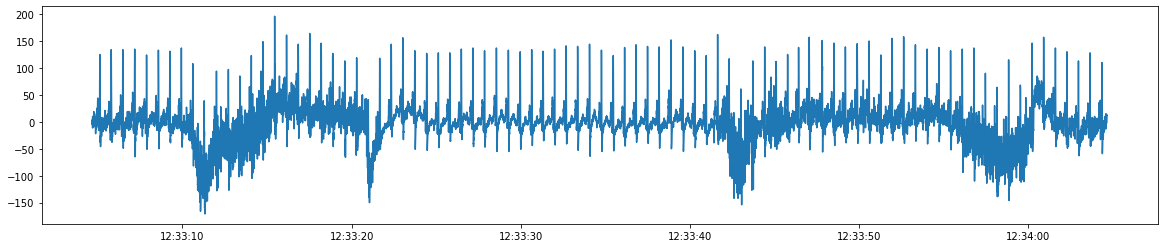

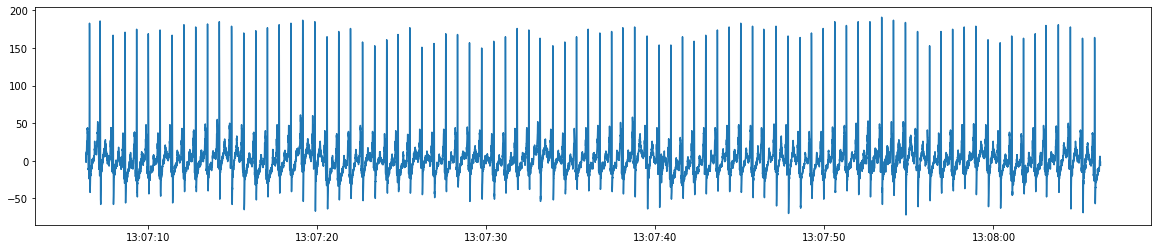

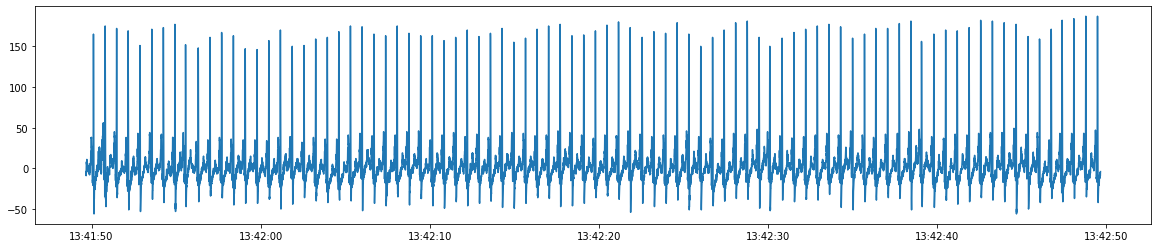

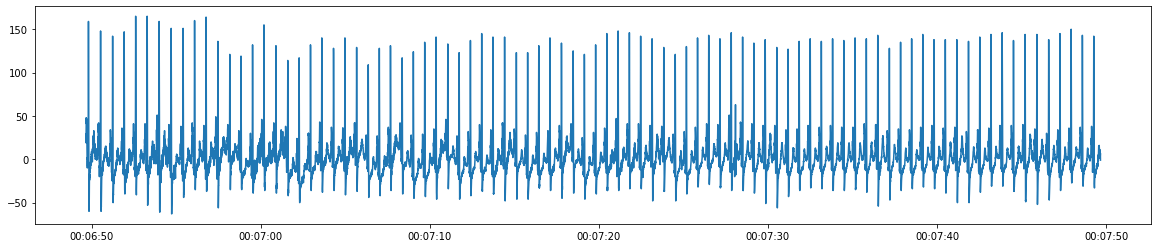

In [22]:
start_idx = 10000
duration = 60
plt.figure(figsize=(20,4))
plt.plot(data_ecg_lead.iloc[start_idx : start_idx + duration*fs])

start_idx = 500000
duration = 60
plt.figure(figsize=(20,4))
plt.plot(data_ecg_lead.iloc[start_idx : start_idx + duration*fs])

start_idx = 1000000
duration = 60
plt.figure(figsize=(20,4))
plt.plot(data_ecg_lead.iloc[start_idx : start_idx + duration*fs])

start_idx = 10000000
duration = 60
plt.figure(figsize=(20,4))
plt.plot(data_ecg_lead.iloc[start_idx : start_idx + duration*fs])

In [67]:
data_vitals, hdr = load_sleep_data(path_vitals_data, idx_to_datetime=1)

In [84]:
data_vitals.hr.dropna()

2019-07-28 12:32:23.000    85.0000
2019-07-28 12:32:23.100    84.8750
2019-07-28 12:32:23.200    84.8125
2019-07-28 12:32:23.300    84.7500
2019-07-28 12:32:23.400    84.6250
                            ...   
2019-07-30 13:42:44.600    78.0000
2019-07-30 13:42:44.700    78.0000
2019-07-30 13:42:44.800    78.0000
2019-07-30 13:42:44.900    78.0000
2019-07-30 13:42:45.000    78.0000
Name: hr, Length: 1762127, dtype: float32

In [ ]:
    # load file object
    ff = h5py.File(filepath, 'r')

    if load_all_signals:
        signals_to_load = list(ff.keys())
    if verbose:
        print(f'signals to load: {signals_to_load}')


    # load the data:
    data = pd.DataFrame([])
    hdr = {}

    # header:
    header_fields = ['study_id', 'MRN', 'fs', 'start_datetime', 'day_night_id']
    header_fields = [x for x in header_fields if x in list(ff.keys())]
    for signal_to_load_tmp in header_fields:
        if signal_to_load_tmp in ['study_id', 'MRN', 'fs']:
            hdr[signal_to_load_tmp] = ff[signal_to_load_tmp][:]
            if hdr[signal_to_load_tmp].shape[0]:
                hdr[signal_to_load_tmp] = hdr[signal_to_load_tmp][0]
        elif signal_to_load_tmp == 'start_datetime':
            t = ff[signal_to_load_tmp][:]
            hdr[signal_to_load_tmp] = pd.to_datetime(f'{t[0]}-{t[1]}-{t[2]} {t[3]}:{t[4]}:{t[5]}.{t[6]}', infer_datetime_format = True)
        elif signal_to_load_tmp == 'day_night_id':
            t = ff[signal_to_load_tmp][:][0]
            hdr[signal_to_load_tmp] = t.decode('utf8')           

    for signal_to_load_tmp in signals_to_load:
        if signal_to_load_tmp in header_fields: continue
        if 'event' in signal_to_load_tmp and not load_events: continue         
        else:
            data[signal_to_load_tmp] = ff[signal_to_load_tmp][:]
    
            if type(data[signal_to_load_tmp].iloc[0]) == np.float16:
                data[signal_to_load_tmp] = data[signal_to_load_tmp].astype('float32')

    ff.close()
    
    if idx_to_datetime:
        data = index_to_datetime_sleepdata(data, hdr)
        
    return data, hdr

In [ ]:
data_vitals, hdr_ = load_sleep_data(path_ecg_data)